# Smart Predict-then-Optimize, on a retail inventory problem

A forecast is not an end in itself. It exists because somebody has to make a
decision, and the decision is scored by money, not by MAPE. This notebook is
about the gap between those two things, and about **PyEPO**, a library for
closing it by putting the optimizer inside the forecaster's loss function.

We build up in two steps.

**Part A — the newsvendor.** One product, one week, one number to choose. Here
the decision-focused answer turns out to be something you already know how to
compute, which makes it the ideal place to build intuition. We also map out
precisely where that convenient answer stops working.

**Part B — a shared constraint.** Once items compete for one container, the
per-item answer from part A is no longer optimal, there is no closed form, and
we need an optimizer in the training loop. This is where PyEPO earns its place.

Throughout, the yardstick is **regret**: how much worse is the decision you
made than the decision you would have made knowing the true demand
distribution? We can compute that exactly, because the data comes from a
simulator whose ground truth we kept.

---

### The libraries

| | |
|---|---|
| [PyEPO](https://github.com/khalil-research/PyEPO) | decision-focused learning: SPO+ and friends |
| [cyclic-boosting](https://github.com/Blue-Yonder-OSS/cyclic-boosting) | quantile regression and Johnson Quantile-Parameterized Distributions |
| [`srsim`](../src/srsim) | this repo: a demand simulator modelled on [FelixWick/demand_forecasting_simulation](https://github.com/FelixWick/demand_forecasting_simulation), plus the glue |

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})

RNG = np.random.default_rng(0)

## 1. A world where we know the answer

The simulator is a re-implementation of Felix Wick's retail demand simulation.
Demand is log-additive in its drivers — hierarchical product and location
effects, a per-product price elasticity, seasonality, promotions that are
**deliberately confounded** with week-of-year and product group, and product
lifecycles — and the observation noise is negative binomial with a
heteroscedastic dispersion, so variance grows faster than the mean.

The one thing we change relative to upstream is the important one: upstream
deletes the true intensity before writing its output, and we keep it. That
single choice is what turns "this policy looked better" into "this policy was
better by this much", because the true distribution of every row is known.

In [2]:
from srsim.pipeline import build_world

world = build_world()          # simulate, split, fit, calibrate (cached on disk)
panel = world.panel

print(f"{len(panel):,} rows | {panel.P_ID.nunique()} products x {panel.L_ID.nunique()} locations "
      f"x {panel.week.nunique()} weeks")
print(f"train weeks 0-{world.config.train_weeks - 1} | "
      f"calibration {world.config.train_weeks}-{world.config.eval_start - 1} | "
      f"evaluation {world.config.eval_start}+")
panel.head(3)[["P_ID", "L_ID", "week", "PG_ID", "promo", "price_ratio", "age", "sales", "lam", "dispersion"]]

15,354 rows | 60 products x 3 locations x 104 weeks
train weeks 0-69 | calibration 70-77 | evaluation 78+


,P_ID,L_ID,week,PG_ID,promo,price_ratio,age,sales,lam,dispersion
0,0,0,0,4,1,0.894371,0,25,10.908148,0.431602
1,0,0,1,4,1,0.896901,0,3,10.747789,0.431602
2,0,0,2,4,0,1.000000,0,8,9.339971,0.331602


`sales` is what a retailer would record. `lam` and `dispersion` are the true
negative-binomial parameters that generated it — visible to us as the
evaluator, and never given to any model.

In [3]:
from srsim.simulate import FEATURE_COLUMNS

print("features a model may use:", FEATURE_COLUMNS)
assert "lam" not in FEATURE_COLUMNS, "ground truth must not leak into features"

features a model may use: ['P_ID', 'L_ID', 'PG_ID', 'week_of_year', 'price_ratio', 'promo', 'trend', 'age']


### The forecast

Three quantile models (cyclic-boosting, pinball loss at 10% / 50% / 90%) are
fitted on the training weeks. Their predictions pin a **Johnson
Quantile-Parameterized Distribution** — a distribution defined by a
symmetric-percentile triplet, with a closed-form quantile function and support
bounded below at zero.

That output contract matters more than the choice of learner. Everything
downstream wants a quantile function: the newsvendor reads one point off it,
part B reads a whole survival curve off it, and tutorial 2 inverts it to
generate demand paths.

The intervals are then **conformalized** on a held-out calibration window —
the same step Presbitero et al. use, and the thing that makes the quantiles
mean what they say.

In [4]:
diag = world.diagnostics
print(f"quantile crossing rate           {diag['crossing_rate']:.3%}")
print(f"interval coverage, raw           {diag['coverage_raw']:.3f}")
print(f"interval coverage, conformalized {diag['coverage_conformal']:.3f}   (nominal {diag['nominal_coverage']:.2f})")
print()
print(f"WAPE of the median forecast      {diag['wape']:.3f}")
print(f"WAPE an oracle would score       {diag['wape_oracle']:.3f}  <- irreducible noise")
print(f"so model error accounts for only {diag['wape'] - diag['wape_oracle']:.3f} of it")

quantile crossing rate           0.303%
interval coverage, raw           0.755
interval coverage, conformalized 0.765   (nominal 0.80)

WAPE of the median forecast      0.615
WAPE an oracle would score       0.489  <- irreducible noise
so model error accounts for only 0.126 of it


That last number is worth sitting with. Most of this forecast's "error" is
noise nobody could have predicted: an oracle that knew every true intensity
exactly would still score a WAPE of ~0.49. Forecast accuracy metrics quietly
mix together *how good the model is* and *how random the world is*, and only
the first is improvable. It is a good reason to be suspicious of accuracy as a
proxy for decision quality — a theme tutorial 2 returns to with data.

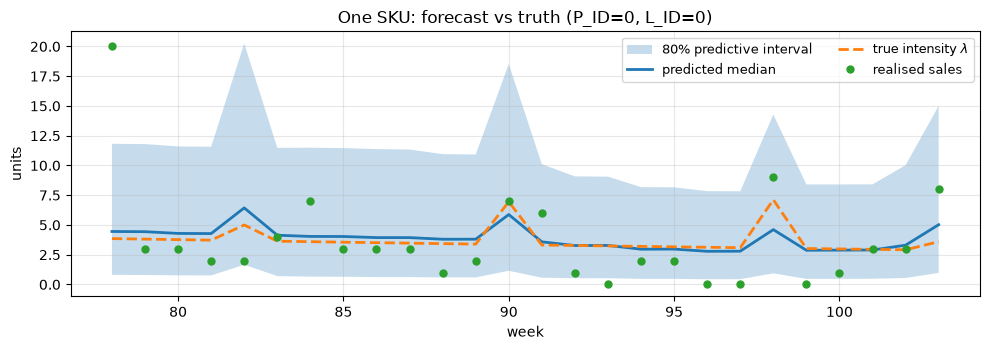

In [5]:
test = world.test
forecast = world.forecast
sku = test[(test.P_ID == test.P_ID.iloc[0]) & (test.L_ID == test.L_ID.iloc[0])].sort_values("week")
idx = sku.index.to_numpy()

fig, ax = plt.subplots()
ax.fill_between(sku.week, forecast.q_low[idx], forecast.q_high[idx], alpha=0.25,
                label="80% predictive interval")
ax.plot(sku.week, forecast.q_median[idx], lw=2, label="predicted median")
ax.plot(sku.week, sku.lam, ls="--", lw=2, label="true intensity $\\lambda$")
ax.plot(sku.week, sku.sales, "o", ms=5, label="realised sales")
ax.set(xlabel="week", ylabel="units", title=f"One SKU: forecast vs truth (P_ID={sku.P_ID.iloc[0]}, L_ID={sku.L_ID.iloc[0]})")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()

---
# Part A — the newsvendor

One SKU, one week. Order $q$ before seeing demand $D$. Each unit of demand you
cannot serve costs $c_u$ in lost margin; each unit you stocked and did not sell
costs $c_o$ to hold. So

$$C(q, D) = c_u (D-q)^+ + c_o (q-D)^+.$$

Now the identity this whole notebook is built on. Writing
$\tau = c_u/(c_u+c_o)$ and letting $\text{pinball}_\tau$ be the usual quantile
regression loss,

$$C(q, D) = (c_u + c_o)\,\cdot\,\text{pinball}_\tau(D, q).$$

**The newsvendor cost *is* the pinball loss, rescaled.** So minimising
empirical decision cost over a class of order policies is *exactly* pinball
quantile regression at level $\tau$ over that same class.

Decision-focused learning for the newsvendor is not a new algorithm. It is
quantile regression at the critical fractile, and the optimal order is
$q^\star = F^{-1}(\tau)$.

Let us check the identity numerically rather than believe it.

In [6]:
from srsim.newsvendor import (
    critical_fractile, expected_cost_nb, newsvendor_cost,
    optimal_order_nb, pinball_loss, regret_nb,
)

C_UNDER, C_OVER = 9.0, 2.0
TAU = float(critical_fractile(C_UNDER, C_OVER))
demand_grid = np.arange(0, 40, dtype=float)

lhs = newsvendor_cost(12.0, demand_grid, C_UNDER, C_OVER)
rhs = (C_UNDER + C_OVER) * pinball_loss(demand_grid, 12.0, TAU)
print(f"c_u = {C_UNDER}, c_o = {C_OVER}  ->  critical fractile tau = {TAU:.3f}")
print("newsvendor cost == (c_u + c_o) * pinball loss :", np.allclose(lhs, rhs))

c_u = 9.0, c_o = 2.0  ->  critical fractile tau = 0.818
newsvendor cost == (c_u + c_o) * pinball loss : True


### Three ways to choose $q$

1. **Point forecast.** Order the predicted mean. The instinctive answer, and
   wrong whenever $c_u \neq c_o$.
2. **Distributional.** Read $q = Q(\tau)$ off the fitted J-QPD.
3. **Decision-focused.** Train directly against the decision loss — which, by
   the identity above, means fitting a quantile model at level $\tau$.

Arms 2 and 3 are the same estimator computed two different ways, so comparing
them is informative in its own right.

Demand is a count, so the optimum is $\min\{q : F(q) \ge \tau\}$: the
continuous quantile must be **ceilinged, not rounded**. Rounding down
silently under-serves.

In [7]:
lam = test["lam"].to_numpy()
dispersion = test["dispersion"].to_numpy()

q_star = optimal_order_nb(lam, dispersion, TAU)              # the unattainable oracle
q_mean = np.ceil(forecast.q_median.copy())                   # arm 1 uses a point forecast
q_qpd = forecast.order_up_to(TAU)                            # arm 2, ceilinged

# The mean of the fitted distribution, for a fair "order the mean" arm.
u_grid = np.linspace(0.005, 0.995, 199)
from srsim.forecast import inverse_transform
q_mean = np.ceil(inverse_transform(forecast, np.tile(u_grid[:, None], (1, len(lam)))).mean(axis=0))

arms = {
    "order the predicted mean": q_mean,
    f"order the J-QPD {TAU:.0%} quantile": q_qpd,
    "oracle (true distribution)": q_star,
}
rows = []
for name, q in arms.items():
    rows.append({
        "arm": name,
        "mean order": q.mean(),
        "expected cost": expected_cost_nb(q, lam, dispersion, C_UNDER, C_OVER).mean(),
        "regret": regret_nb(q, lam, dispersion, C_UNDER, C_OVER).mean(),
    })
pd.DataFrame(rows).set_index("arm").round(3)

,mean order,expected cost,regret
arm,,,
order the predicted mean,10.177,35.764,15.688
order the J-QPD 82% quantile,16.283,29.735,9.659
oracle (true distribution),15.270,20.076,0.000


Ordering the mean is not a small mistake. With underage costing 4.5× overage,
the cost-minimising service level is 82%, and the mean sits far below that
quantile for a right-skewed demand distribution.

Note what regret is measuring here: the gap to the best decision obtainable
**from the true conditional distribution**, not to a clairvoyant who saw the
realised demand. The oracle row is zero by construction. Every other row is
the price of not knowing the distribution exactly.

### Where the J-QPD is doing the work

Arm 2 reads $Q(\tau)$ off a distribution pinned at the 10th, 50th and 90th
percentiles. For $\tau$ inside that range it is interpolating. For $\tau$
outside it, the parametric form is extrapolating, and the answer is as good as
the J-QPD's tail assumption.

That distinction is invisible until you look for it, so let us look.

In [8]:
rows = []
for tau in (0.5, 0.7, 0.82, 0.9, 0.95, 0.99):
    q_hat = forecast.order_up_to(tau)
    q_true = optimal_order_nb(lam, dispersion, tau)
    inside = world.config.alpha <= tau <= 1 - world.config.alpha
    rows.append({
        "tau": tau,
        "within pinned range": "yes" if inside else "NO (extrapolating)",
        "mean order (J-QPD)": q_hat.mean(),
        "mean order (oracle)": q_true.mean(),
        "median abs error": np.median(np.abs(q_hat - q_true)),
    })
pd.DataFrame(rows).set_index("tau").round(2)

,within pinned range,mean order (J-QPD),mean order (oracle),median abs error
tau,,,,
0.50,yes,7.66,9.05,2.0
0.70,yes,12.10,12.41,3.0
0.82,yes,16.35,15.32,4.0
0.90,yes,21.35,18.38,4.0
0.95,NO (extrapolating),27.63,21.74,6.0
0.99,NO (extrapolating),44.87,28.99,12.0


The error grows steadily with $\tau$ even inside the pinned range, and then
jumps once we leave it: by $\tau = 0.99$ the J-QPD wants to order about 55%
more than the oracle. The number still comes out, and it is now the J-QPD's
functional form talking rather than the data. If your cost ratio implies a 99%
service level, pin the distribution somewhere near 99% — do not pin it at 90%
and extrapolate.

### Six ways the simple answer breaks

The equivalence "decision-focused training = quantile regression" is exact,
but it is exact under hypotheses. Each of these is a reason the rest of this
series exists.

In [9]:
from srsim.newsvendor import equivalence_caveats

for i, caveat in enumerate(equivalence_caveats(), 1):
    print(f"{i}. {caveat}\n")

1. Cost must be exactly two-slope piecewise-linear in q. A fixed ordering cost, salvage value, or quantity discount breaks the pinball identity.

2. Single period, no carryover. Once leftover stock survives into next week -- the entire premise of an (R,s,Q) policy -- per-period costs stop being separable. With lead time L the result generalises to the distribution of lead-time demand, not single-period demand.

3. q must be unconstrained. Add a shared capacity across items and the per-item optimum is no longer its own fractile: it becomes water-filling against a common shadow price, q_j* = F_j^-1((c_u - mu)/(c_u + c_o)).

4. Under misspecification pinball still returns the decision-optimal member of the model class, while fitting by MSE and plugging in does not. This is the real argument for decision-focused learning -- not that it is always better, but that it optimises the thing you care about.

5. It delivers one fractile, not a distribution. Anything that needs whole sampled demand

Number 3 is the one we attack next. Add a constraint that couples the items —
one container, many SKUs — and the per-item critical fractile is no longer
optimal. The items now compete, and the optimal order for each depends on a
shadow price that only exists once you solve the joint problem.

There is no closed form for that. There is an optimizer.

---
# Part B — a shared constraint, and PyEPO

## Why inventory does not fit PyEPO out of the box

It is worth being blunt about this, because skipping it teaches the wrong
lesson. PyEPO and SPO+ assume a problem of the form

$$\min_w \; c(x)^\top w \quad \text{subject to} \quad w \in S,$$

with the uncertainty in the **objective coefficients** and the feasible set $S$
**fixed**. Inventory resists that in two ways:

1. **Demand naturally enters the constraints**, not the objective — inventory
   balance is a constraint. That rules out multi-period lot-sizing entirely:
   regret is not even well defined when the feasible set moves with the
   uncertainty.
2. **The value of stock is concave in quantity.** Each additional unit is less
   likely to sell than the last. PyEPO needs linearity.

Point 2 has a clean fix, and it is the key modelling step of this notebook.

## Linearising with tranches

Build each SKU's stock out of blocks of $w$ units. The value of the block that
takes stock from $q-1$ to $q$ is the margin you earn if that unit sells, minus
the holding cost if it does not:

$$v(q) = m \cdot P(D \ge q) - h \cdot P(D < q) = (m+h)\,P(D \ge q) - h,$$

and block $b$'s coefficient is the average of $v(q)$ over the units it
contains. Two consequences make this the right choice:

* **The cost vector is an affine transform of a survival function.** That is
  exactly what a J-QPD predicts. Part B predicts the same object as part A.
* **The uncoupled optimum is the newsvendor.** Drop the capacity and the LP
  fills blocks while $v > 0$, i.e. while $P(D \ge q) \ge h/(m+h)$ — the
  critical fractile. Part A is the special case.

The full problem allocates one shared inbound container across SKUs sitting in
different stores:

$$\max_x \sum_{j,b} v_{j,b}\, x_{j,b} \quad \text{s.t.} \quad
\sum_{j,b} x_{j,b} \le K, \quad
\sum_{b} x_{j,b} \le C_{s(j)}, \quad 0 \le x_{j,b} \le w.$$

The constraint matrix is a laminar family (items nested in stores, plus the
grand total), hence totally unimodular, so the LP relaxation already has
integral vertices. We check that rather than trusting it.

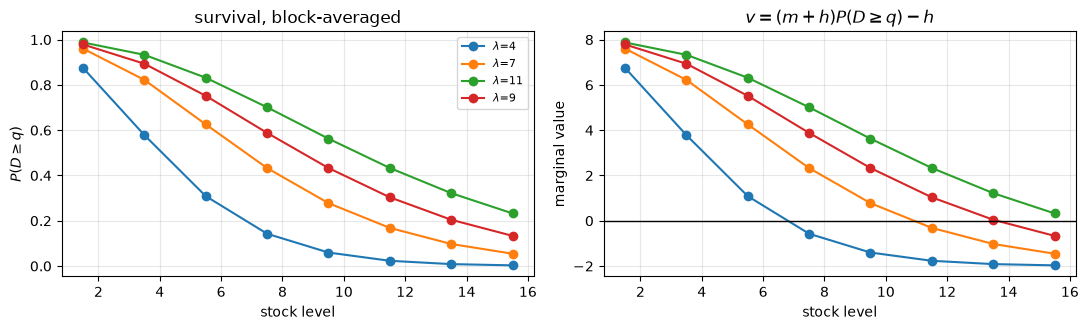

In [10]:
from srsim.allocation import TrancheAllocationModel, TrancheSpec, marginal_values, true_survival_matrix

SPEC = TrancheSpec(width=2, n_blocks=8)
demo_lam = np.array([4.0, 7.0, 11.0, 9.0])
demo_disp = np.full(4, 0.25)
demo_margin, demo_holding = np.full(4, 8.0), np.full(4, 2.0)

surv = true_survival_matrix(demo_lam, demo_disp, SPEC)
value = marginal_values(surv, demo_margin, demo_holding)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
levels = SPEC.unit_levels.mean(axis=1)
for i, lam_i in enumerate(demo_lam):
    axes[0].plot(levels, surv[i], "o-", label=f"$\\lambda$={lam_i:.0f}")
    axes[1].plot(levels, value[i], "o-")
axes[0].set(xlabel="stock level", ylabel="$P(D \\geq q)$", title="survival, block-averaged")
axes[1].axhline(0, color="k", lw=1)
axes[1].set(xlabel="stock level", ylabel="marginal value", title="$v = (m+h)P(D \\geq q) - h$")
axes[0].legend(fontsize=8)
plt.tight_layout()

The right-hand curve crossing zero *is* the newsvendor solution: stock every
block whose marginal value is positive. A capacity constraint will stop us
before that point and force the blocks to compete.

### The PyEPO model

A custom `optModel` over `scipy.optimize.linprog`. PyEPO hard-depends on no
solver, and `linprog` is a stateless function, so there is no solver object to
trip over PyEPO 2.x's constructor-argument snapshotting.

Two details are easy to get wrong and silent when you do — `solve()` must
return a **scalar** objective in **maximisation sense**. A shape-`(1,)` value
broadcasts to `(batch, batch)` inside `SPOPlus` and still reduces to a scalar
loss, so you get a wrong gradient and no error message.

In [11]:
uncapped = TrancheAllocationModel([0, 0, 1, 1], SPEC.width, SPEC.n_blocks, [1e6, 1e6], 1e6)
uncapped.setObj(value.ravel())
sol, obj = uncapped.solve()
allocated = sol.reshape(4, SPEC.n_blocks).sum(axis=1)

print("solution is integral        :", np.allclose(sol, np.round(sol)))
print("objective is a plain scalar :", isinstance(obj, float))
print()
print("uncapacitated LP stock  :", allocated)
print("newsvendor critical q*  :", optimal_order_nb(demo_lam, demo_disp, critical_fractile(demo_margin, demo_holding)))
print("\n(agreeing to within the block width of", SPEC.width, "units)")

solution is integral        : True
objective is a plain scalar : True

uncapacitated LP stock  : [ 6. 10. 16. 14.]
newsvendor critical q*  : [ 6. 10. 16. 13.]

(agreeing to within the block width of 2 units)


The LP reduces to the newsvendor when the coupling is removed. Now switch the
capacity on and the problem becomes genuinely joint.

### Three arms

All three solve the *same* LP with the *same* capacities. They differ only in
where the cost vector comes from.

| arm | cost vector |
|---|---|
| **plug-in** | read straight off the fitted J-QPD — classical predict-then-optimize, no learning |
| **two-stage** | a predictor trained to match the true cost vector by MSE, then optimized |
| **SPO+** | the *same* predictor, trained with the LP inside the loss |

The two trained arms share an architecture, so the comparison isolates the loss.

The predictor is **monotone by construction**: it emits non-negative decrements
which are accumulated into a decreasing survival curve, rather than $B$ free
numbers. The LP is only well posed if marginal value decreases with stock
level, so the decision structure dictates the network architecture. That is the
whole idea of decision-focused learning, showing up in the model class rather
than the loss.

In [12]:
from pyepo.data.dataset import optDataLoader, optDataset
from pyepo.metric import calRegret, regret

from srsim.dfl import TrancheNet, build_instances, train_spo, train_two_stage

N_ITEMS = 12
train_set = build_instances(world, SPEC, 600, N_ITEMS, np.random.default_rng(0))
test_set = build_instances(world, SPEC, 200, N_ITEMS, np.random.default_rng(99))

# Size the container so it actually binds: ~55% of what the unconstrained
# optimum would stock. An unbinding constraint makes part B into part A.
probe = TrancheAllocationModel(train_set.store_of_item, SPEC.width, SPEC.n_blocks, [1e6] * 3, 1e6)
totals = []
for c in train_set.costs_true[:50]:
    probe.setObj(c)
    totals.append(probe.solve()[0].sum())
capacity = float(np.median(totals) * 0.55)

opt_model = TrancheAllocationModel(
    train_set.store_of_item, SPEC.width, SPEC.n_blocks,
    store_caps=[capacity / 3 * 1.2] * 3, total_capacity=capacity,
)
print(f"container capacity {capacity:.0f} units vs {np.median(totals):.0f} unconstrained -> the constraint binds")
print(f"decision variables: {opt_model.num_cost} ({N_ITEMS} items x {SPEC.n_blocks} blocks)")

container capacity 66 units vs 120 unconstrained -> the constraint binds
decision variables: 96 (12 items x 8 blocks)


In [13]:
ds_train = optDataset(opt_model, train_set.feats, train_set.costs_true)
ds_test = optDataset(opt_model, test_set.feats, test_set.costs_true)
dl_test = optDataLoader(ds_test, batch_size=32, shuffle=False)

  0%|          | 0/600 [00:00<?, ?it/s]

  7%|▋         | 41/600 [00:00<00:01, 402.19it/s]

 14%|█▎        | 82/600 [00:00<00:01, 391.12it/s]

 20%|██        | 122/600 [00:00<00:01, 390.86it/s]

 27%|██▋       | 162/600 [00:00<00:01, 391.18it/s]

...

 40%|████      | 80/200 [00:00<00:00, 371.31it/s]

 59%|█████▉    | 118/200 [00:00<00:00, 374.93it/s]

 79%|███████▉  | 158/200 [00:00<00:00, 381.97it/s]

 98%|█████████▊| 197/200 [00:00<00:00, 378.08it/s]

100%|██████████| 200/200 [00:00<00:00, 377.34it/s]

`optDataset` pre-solves the true optimum for every instance at construction —
that is the `w` and `z` that SPO+ needs.

One naming trap worth flagging: `pyepo.twostage` is **not** two-stage
stochastic programming. It is the decoupled predict-then-optimize baseline.

Now train. The honest experiment runs two model classes, because which one you
use changes the answer:

* a **linear** head, which cannot represent a demand process that is
  exponential in its features — the misspecified regime where decision-focused
  learning is supposed to help;
* an **MLP**, which has a fighting chance of being right everywhere.

In [14]:
def build_net(hidden: int, seed: int = 0) -> TrancheNet:
    net = TrancheNet(N_ITEMS, SPEC.n_blocks, hidden=hidden, seed=seed)
    net.fit_scaler(train_set.feats)
    return net


def test_mse(net: TrancheNet) -> float:
    with torch.no_grad():
        pred = net(torch.as_tensor(test_set.feats))
    return float(((pred - torch.as_tensor(test_set.costs_true)) ** 2).mean())


results = []
for hidden, label in [(0, "linear (misspecified)"), (32, "MLP-32")]:
    two_stage = build_net(hidden)
    train_two_stage(two_stage, ds_train, epochs=25)
    spo = build_net(hidden)
    train_spo(spo, ds_train, opt_model, epochs=25)
    for name, net in (("two-stage (MSE)", two_stage), ("SPO+", spo)):
        results.append({
            "model class": label, "trained with": name,
            "test MSE": test_mse(net), "normalized regret": regret(net, opt_model, dl_test),
        })

plugin_regret = sum(
    calRegret(opt_model, test_set.costs_plugin[i], test_set.costs_true[i], float(ds_test.objs[i]))
    for i in range(len(test_set.feats))
) / sum(abs(float(z)) for z in ds_test.objs)
results.append({"model class": "-", "trained with": "plug-in J-QPD (no learning)",
                "test MSE": np.nan, "normalized regret": plugin_regret})

pd.DataFrame(results).set_index(["model class", "trained with"]).round(4)

test MSE  normalized regret
model class           trained with                                            
linear (misspecified) two-stage (MSE)                4.3906             0.0785
                      SPO+                           6.1095             0.0764
MLP-32                two-stage (MSE)                2.1314             0.0416
                      SPO+                           2.0143             0.0288
-                     plug-in J-QPD (no learning)       NaN             0.0895

Read the table twice.

**First, regret.** SPO+ beats two-stage MSE in both model classes, and the
plug-in J-QPD — a perfectly reasonable forecast, used the classical way — is
worst of all. Learning the decision-relevant object beats reading it off a
general-purpose forecast.

**Second, MSE.** For the linear model, SPO+ achieves *worse* MSE and *better*
regret than the two-stage arm. This is the signature of decision-focused
learning: a predictor that cannot be right everywhere should be right where
the decision is sensitive, and it buys that accuracy by being wronger where
the decision does not care. If you were tracking forecast accuracy in
production, you would have rejected the better decision-maker.

One honest caveat, because it is easy to rig this experiment. With a
well-specified predictor and enough data, two-stage MSE is asymptotically
optimal and SPO+ is a surrogate for the thing you actually want — the
advantage can shrink or reverse. We report what we measured, on this DGP, at
this sample size. Re-run with different seeds before believing any particular
percentage.

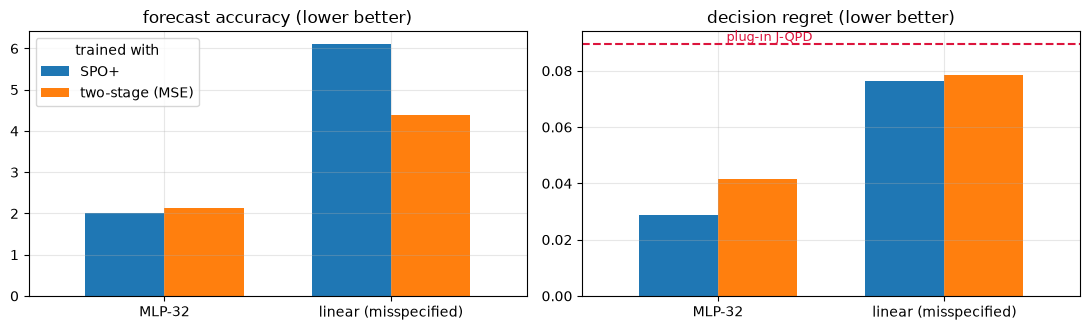

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
frame = pd.DataFrame(results).dropna()
for ax, metric, title in zip(axes, ["test MSE", "normalized regret"],
                             ["forecast accuracy (lower better)", "decision regret (lower better)"]):
    pivot = frame.pivot(index="model class", columns="trained with", values=metric)
    pivot.plot.bar(ax=ax, rot=0, width=0.7, legend=(metric == "test MSE"))
    ax.set(title=title, xlabel="")
axes[1].axhline(plugin_regret, color="crimson", ls="--", lw=1.5)
axes[1].text(0.02, plugin_regret, " plug-in J-QPD", color="crimson", va="bottom", fontsize=9)
plt.tight_layout()

---
## What SPO+ assumes, and where that runs out

It is tempting to end with "so always use the full distribution". That would
be the wrong lesson, and the reason is worth being precise about.

The objective here is **linear in the cost vector** and the feasible set is
**fixed**. Therefore

$$\mathbb{E}\big[c^\top w\big] = \mathbb{E}[c]^\top w,$$

and the optimal decision depends on the distribution of $c$ **only through its
conditional mean**. Collapsing the distribution to a point is not a loss of
information — for this problem it is *exactly sufficient*. SPO+ is not
throwing anything away; it is learning *which* point matters.

The distribution starts to matter when one of these holds:

1. the objective is **nonlinear in the uncertainty** — as in the newsvendor,
   which is why part A needed a quantile and not a mean;
2. you are **risk-averse**, and care about the tail of the cost distribution
   rather than its average;
3. uncertainty enters the **constraints**.

Notice that our tranche construction smuggled (1) past the linearity
requirement: the coefficients $v_{j,b}$ *are* a discretised survival function,
so distributional information entered through the cost vector rather than
through a risk measure. That trick works because the decision was a one-shot
allocation.

It stops working when the decision is a **policy over time** — order some now,
watch what sells, reorder later — and the cost is computed by a simulator with
branches and delays rather than a dot product. There is no linear objective to
put the survival function into, and no argmin to differentiate through.

That is exactly the problem Presbitero et al. solve at Zalando, and it is
where **[tutorial 2](02_presbitero_zeos.ipynb)** picks up.

In [16]:
print("Part A carried forward:", f"critical fractile tau = {TAU:.2f}, the myopic newsvendor policy")
print("Part B carried forward:", f"the J-QPD survival curve, {SPEC.n_blocks} blocks of {SPEC.width} units")
print("\nTutorial 2 reuses both: the newsvendor becomes a baseline policy, and the")
print("J-QPD becomes the scenario generator for a 12-week discrete-event simulation.")

Part A carried forward: critical fractile tau = 0.82, the myopic newsvendor policy
Part B carried forward: the J-QPD survival curve, 8 blocks of 2 units

Tutorial 2 reuses both: the newsvendor becomes a baseline policy, and the
J-QPD becomes the scenario generator for a 12-week discrete-event simulation.
